# Employee Turnover Prediction using Logistic Regression

## Problem Statement

TalentCore Pvt. Ltd. is facing increasing employee resignations which lead to:

- Recruitment costs
- Project delays
- Loss of experienced employees

Goal:
Build a Machine Learning model that predicts whether an employee is likely to leave the company.

Target Variable:
Employee_Turnover

1 = Employee Left
0 = Employee Stayed

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt

In [2]:
import sys
print(sys.executable)
print(sys.version)

C:\Users\kapta\anaconda3\envs\garak_env\python.exe
3.10.19 | packaged by Anaconda, Inc. | (main, Oct 21 2025, 16:41:31) [MSC v.1929 64 bit (AMD64)]


In [3]:
!where python
!where pip

C:\Users\kapta\anaconda3\python.exe
C:\Python313\python.exe
C:\Users\kapta\AppData\Local\Programs\Python\Python311\python.exe
C:\Users\kapta\anaconda3\Scripts\pip.exe
C:\Python313\Scripts\pip.exe
C:\Users\kapta\AppData\Local\Programs\Python\Python311\Scripts\pip.exe


In [4]:
import sys
!{sys.executable} -m pip install plotly

In [5]:
import plotly.express as px
import plotly.graph_objects as go

print("Plotly Installed Successfully")

Plotly Installed Successfully


In [6]:
import numpy as np
import pandas as pd
import streamlit as st
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

### Why these libraries?

- NumPy → numerical calculations
- Pandas → data handling
- Matplotlib & Seaborn → visualization
- Scikit-Learn → machine learning algorithms
- Metrics → evaluate model performance

In [7]:
df = pd.read_csv("employee_turnover.csv")
df.head()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
0,0.562326,0.141129,0.123989,0.347583,0.330353,0.328853,0.600933,0.315990,0.768736,0.090671,0.324786,0.669193,0.602932,0.105486,0.217344,0
1,0.017041,0.559047,0.511203,0.793908,0.423550,0.553450,0.742009,0.897146,0.380035,0.601633,0.694611,0.043271,0.800761,0.482484,0.030056,0
2,0.774699,0.604371,0.798174,0.260500,0.804034,0.131800,0.775178,0.830947,0.218726,0.972936,0.153476,0.701336,0.705275,0.023555,0.107638,1
3,0.628174,0.385249,0.230104,0.516809,0.272248,0.589249,0.482409,0.090507,0.402746,0.132842,0.305973,0.549688,0.600531,0.093620,0.168190,0
4,0.799183,0.199967,0.839029,0.247927,0.341934,0.076818,0.055356,0.680860,0.923341,0.493017,0.844094,0.793751,0.664679,0.712494,0.670000,0


In [8]:
feature_ranges = {

"Job_Satisfaction":[1,5],

"Performance_Rating":[1,5],

"Years_At_Company":[0,40],

"Work_Life_Balance":[1,5],

"Distance_From_Home":[0,50],

"Monthly_Income":[10000,300000],

"Education_Level":[1,5],

"Age":[18,65],

"Num_Companies_Worked":[0,20],

"Employee_Role":[0,10],

"Annual_Bonus":[0,1000000],

"Training_Hours":[0,100],

"Department":[0,10]
}

The dataset is loaded into a Pandas DataFrame.

The first 5 rows are displayed to understand the structure of the data.

In [9]:
print(df.shape)

df.info()

(1350, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1350 entries, 0 to 1349
Data columns (total 16 columns):
 #   Column                                   Non-Null Count  Dtype  
---  ------                                   --------------  -----  
 0   Job_Satisfaction                         1350 non-null   float64
 1   Performance_Rating                       1350 non-null   float64
 2   Years_At_Company                         1350 non-null   float64
 3   Work_Life_Balance                        1350 non-null   float64
 4   Distance_From_Home                       1350 non-null   float64
 5   Monthly_Income                           1350 non-null   float64
 6   Education_Level                          1350 non-null   float64
 7   Age                                      1350 non-null   float64
 8   Num_Companies_Worked                     1350 non-null   float64
 9   Employee_Role                            1350 non-null   float64
 10  Annual_Bonus                         

This step helps us understand:

- Number of rows and columns
- Data types
- Missing values
- Memory usage

In [10]:
df.describe()

,Job_Satisfaction,Performance_Rating,Years_At_Company,Work_Life_Balance,Distance_From_Home,Monthly_Income,Education_Level,Age,Num_Companies_Worked,Employee_Role,Annual_Bonus,Training_Hours,Department,Annual_Bonus_Squared,Annual_Bonus_Training_Hours_Interaction,Employee_Turnover
count,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1350.000000,1.350000e+03,1350.000000,1350.000000
mean,0.506386,0.487061,0.484761,0.499442,0.494884,0.509909,0.504329,0.500164,0.516149,0.506091,0.493360,0.486843,0.485767,3.291479e-01,0.240653,0.497778
std,0.291505,0.283808,0.282758,0.293013,0.289248,0.290110,0.295693,0.294835,0.295072,0.284901,0.292929,0.288342,0.285077,2.986314e-01,0.222281,0.500180
min,0.001738,0.000546,0.001545,0.000166,0.001319,0.005015,0.000424,0.000231,0.000150,0.000903,0.000491,0.001293,0.001595,2.410000e-07,0.000247,0.000000
25%,0.263051,0.238538,0.249651,0.246399,0.244162,0.263235,0.249894,0.239224,0.247978,0.269517,0.247274,0.233357,0.244944,6.114448e-02,0.058694,0.000000
50%,0.525340,0.468457,0.485414,0.495572,0.501617,0.532388,0.509448,0.499964,0.531408,0.504640,0.498490,0.475214,0.468982,2.484923e-01,0.165438,0.000000
75%,0.750987,0.724088,0.721622,0.753108,0.743938,0.761090,0.755113,0.767168,0.775888,0.761640,0.740231,0.747609,0.725870,5.479425e-01,0.367042,1.000000
max,0.998692,0.999957,0.999722,0.999931,0.997813,0.999143,0.999794,0.998365,0.999962,0.999964,0.998211,0.998330,0.999386,9.964245e-01,0.930338,1.000000


Provides statistical information:

- Mean
- Median
- Standard Deviation
- Minimum
- Maximum

In [11]:
df.isnull().sum()

Job_Satisfaction                           0
Performance_Rating                         0
Years_At_Company                           0
Work_Life_Balance                          0
Distance_From_Home                         0
Monthly_Income                             0
Education_Level                            0
Age                                        0
Num_Companies_Worked                       0
Employee_Role                              0
Annual_Bonus                               0
Training_Hours                             0
Department                                 0
Annual_Bonus_Squared                       0
Annual_Bonus_Training_Hours_Interaction    0
Employee_Turnover                          0
dtype: int64

Machine Learning models cannot handle missing values directly.

This step identifies any null values in the dataset.

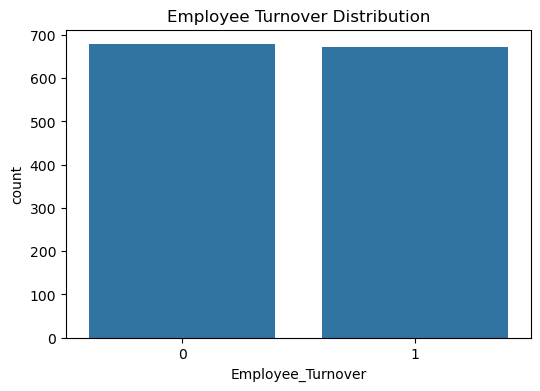

In [12]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Employee_Turnover',
    data=df
)

plt.title("Employee Turnover Distribution")

plt.show()

## Target Variable Distribution

This visualization shows the number of employees who:

- Stayed in the company
- Left the company

It helps identify class imbalance.

Understanding class balance is important.

This plot shows how many employees left versus stayed.

In [13]:
turnover_rate = (
    df['Employee_Turnover']
    .value_counts(normalize=True)
    *100
)

print(turnover_rate)

Employee_Turnover
0    50.222222
1    49.777778
Name: proportion, dtype: float64


## Class Balance Analysis

Understanding the proportion of employees leaving versus staying helps determine whether balancing techniques are required.

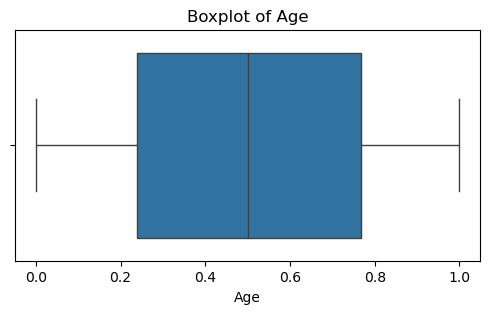

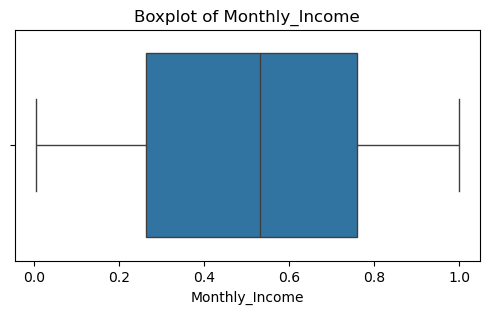

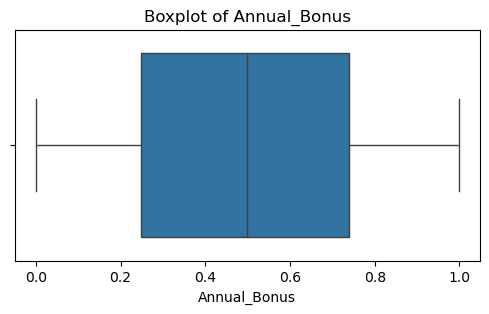

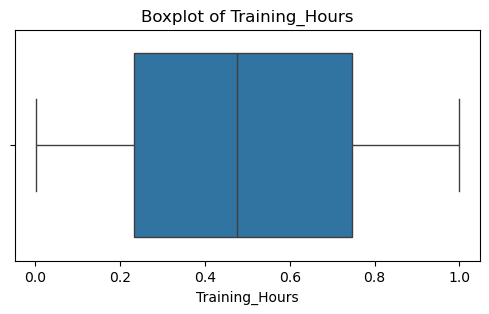

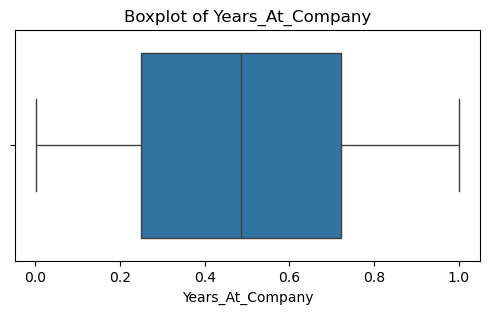

In [14]:
numerical_columns = [
    'Age',
    'Monthly_Income',
    'Annual_Bonus',
    'Training_Hours',
    'Years_At_Company'
]

for col in numerical_columns:

    plt.figure(figsize=(6,3))

    sns.boxplot(
        x=df[col]
    )

    plt.title(f"Boxplot of {col}")

    plt.show()

## Outlier Analysis

Boxplots help identify extreme observations that may affect model performance.

Outliers can distort model learning and should be investigated.

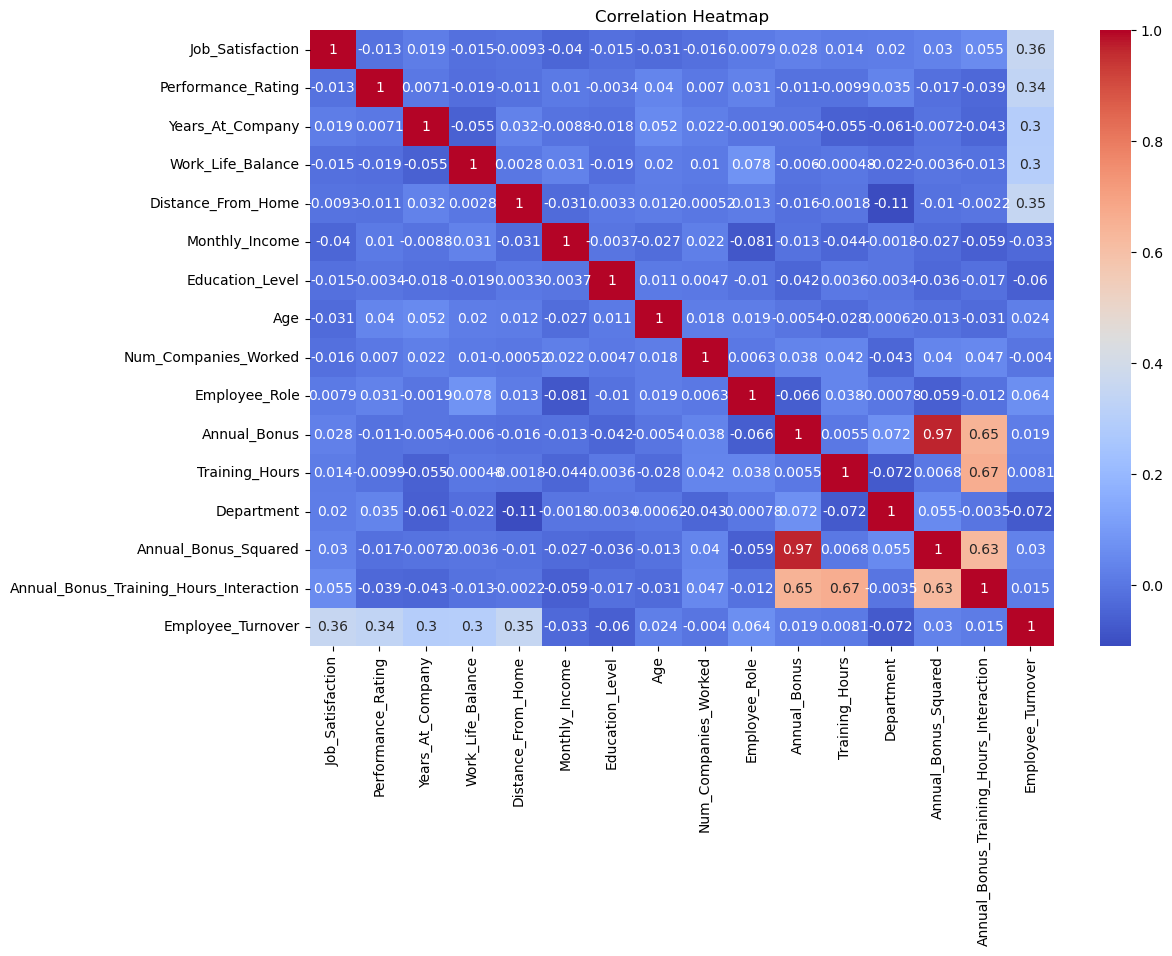

In [15]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

## Correlation Analysis

Correlation helps identify:

- Strong feature relationships
- Potential multicollinearity
- Variables influencing employee turnover

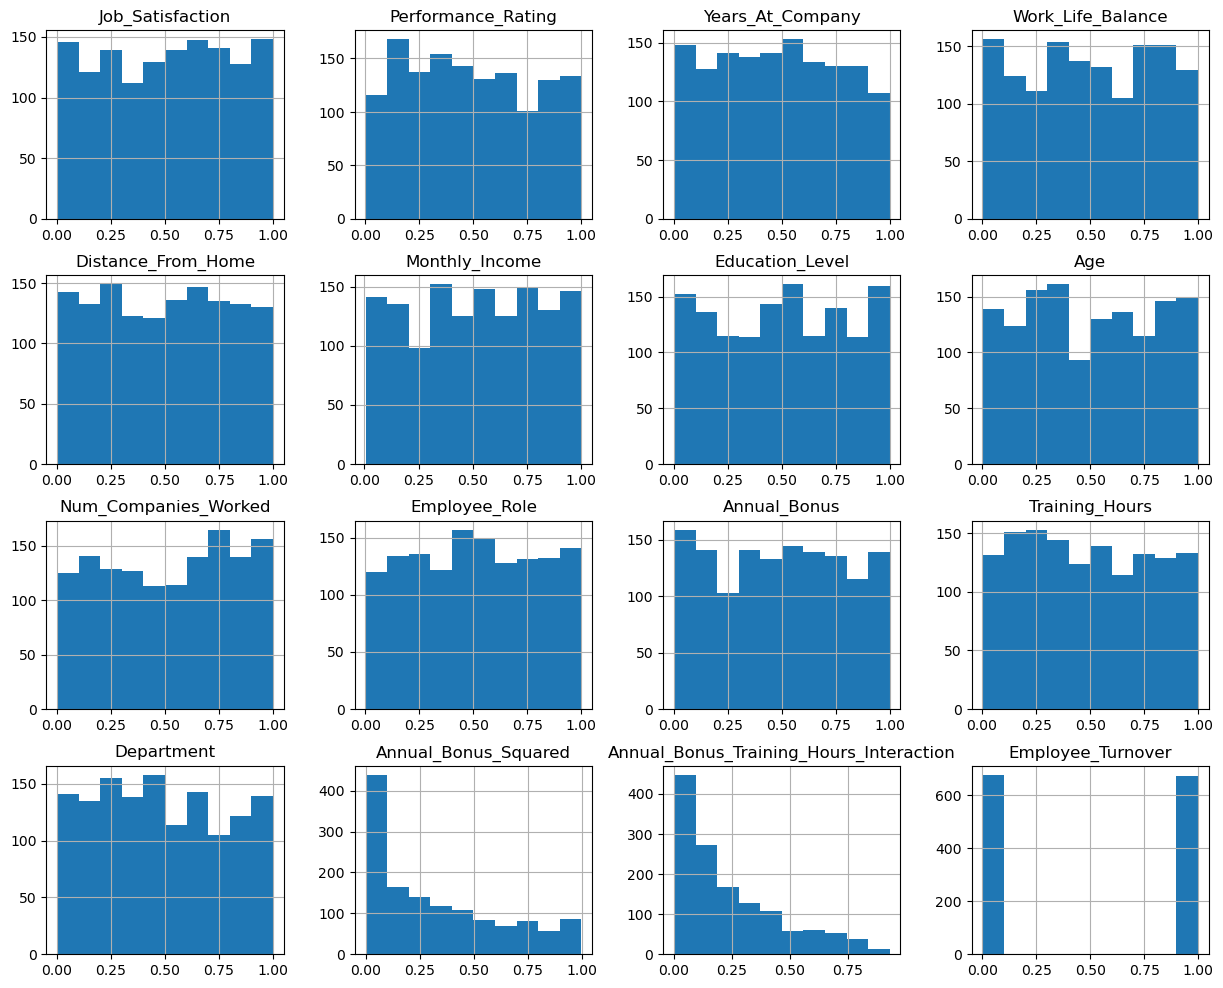

In [16]:
df.hist(figsize=(15,12))
plt.show()

Visualizing feature distributions helps identify:

- Skewness
- Outliers
- Data spread

In [17]:
df["Employee_Turnover"] = 1 - df["Employee_Turnover"]

In [18]:
X = df.drop("Employee_Turnover", axis=1)
y = df["Employee_Turnover"]

## Feature and Target Separation

Features (X) are used as inputs.

Target (y) represents employee turnover status.

In [19]:
from sklearn.model_selection import train_test_split

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

80% data is used for training.

20% data is used for testing.

In [21]:
from sklearn.preprocessing import StandardScaler

In [22]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

Logistic Regression performs better when features are on similar scales.

StandardScaler converts data into standard normal distribution.

In [23]:
from sklearn.linear_model import LogisticRegression

In [24]:
baseline_model = LogisticRegression()

baseline_model.fit(
    X_train_scaled,
    y_train
)

baseline_pred = baseline_model.predict(
    X_test_scaled
)

In [25]:
from sklearn.metrics import classification_report

In [26]:
print(
    classification_report(
        y_test,
        baseline_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       125
           1       0.86      0.89      0.87       145

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270



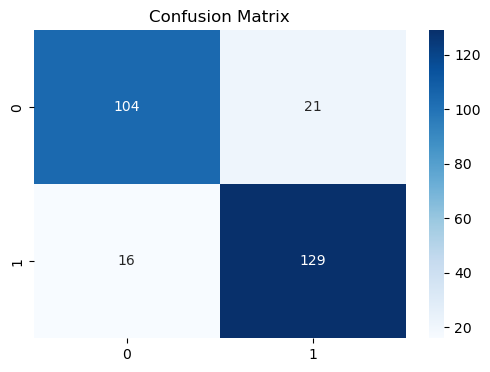

In [27]:
cm = confusion_matrix(
    y_test,
    baseline_pred
)

plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Confusion Matrix")

plt.show()

## Baseline Model Evaluation

The confusion matrix and classification report provide:

- Accuracy
- Precision
- Recall
- F1 Score

These metrics evaluate model effectiveness.

In [28]:
l1_model = LogisticRegression(
    penalty='l1',
    solver='liblinear',
    C=1
)

l1_model.fit(
    X_train_scaled,
    y_train
)

l1_pred = l1_model.predict(
    X_test_scaled
)

In [29]:
print(
    classification_report(
        y_test,
        l1_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       125
           1       0.86      0.89      0.87       145

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270



## L1 Regularization

L1 regularization can automatically eliminate less important features by reducing coefficients to zero.

This may improve model simplicity and interpretability.

In [30]:
l2_model = LogisticRegression(
    penalty='l2',
    C=1
)

l2_model.fit(
    X_train_scaled,
    y_train
)

l2_pred = l2_model.predict(
    X_test_scaled
)

In [31]:
print(
    classification_report(
        y_test,
        l2_pred
    )
)

              precision    recall  f1-score   support

           0       0.87      0.83      0.85       125
           1       0.86      0.89      0.87       145

    accuracy                           0.86       270
   macro avg       0.86      0.86      0.86       270
weighted avg       0.86      0.86      0.86       270



## L2 Regularization

L2 regularization penalizes large coefficients and helps reduce overfitting while retaining all features.

In [32]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'C':[0.01,0.1,1,10,100]
}

grid_search = GridSearchCV(
    LogisticRegression(),
    param_grid,
    cv=5
)

grid_search.fit(
    X_train_scaled,
    y_train
)

print(grid_search.best_params_)

{'C': 0.1}


## Hyperparameter Tuning

GridSearchCV tests multiple parameter combinations and selects the best-performing model using cross-validation.

In [33]:
y_prob = l2_model.predict_proba(
    X_test_scaled
)[:,1]

auc_score = roc_auc_score(
    y_test,
    y_prob
)

print("ROC AUC:", auc_score)

ROC AUC: 0.9537103448275861


In [34]:
from sklearn.metrics import roc_curve

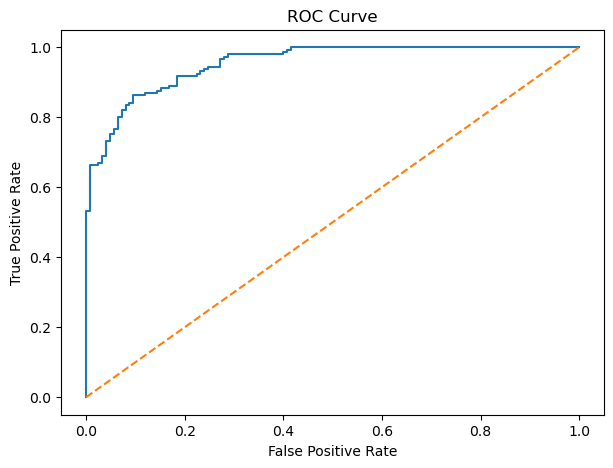

In [35]:
fpr,tpr,thresholds = roc_curve(
    y_test,
    y_prob
)

plt.figure(figsize=(7,5))

plt.plot(fpr,tpr)

plt.plot(
    [0,1],
    [0,1],
    '--'
)

plt.title("ROC Curve")

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.show()

In [36]:
feature_importance = pd.DataFrame({
    'Feature':X.columns,
    'Coefficient':l2_model.coef_[0]
})

feature_importance = feature_importance.sort_values(
    by='Coefficient',
    ascending=False
)

feature_importance

,Feature,Coefficient
6,Education_Level,0.239434
5,Monthly_Income,0.181728
14,Annual_Bonus_Training_Hours_Interaction,0.109494
10,Annual_Bonus,0.102383
8,Num_Companies_Worked,0.064418
12,Department,0.048897
7,Age,0.031348
9,Employee_Role,-0.041778
11,Training_Hours,-0.136064
13,Annual_Bonus_Squared,-0.241330


In [37]:
comparison = pd.DataFrame({
    "Model":["Baseline","L1","L2"],
    "Accuracy":[
        accuracy_score(y_test, baseline_pred),
        accuracy_score(y_test, l1_pred),
        accuracy_score(y_test, l2_pred)
    ]
})

comparison

,Model,Accuracy
0,Baseline,0.862963
1,L1,0.862963
2,L2,0.862963


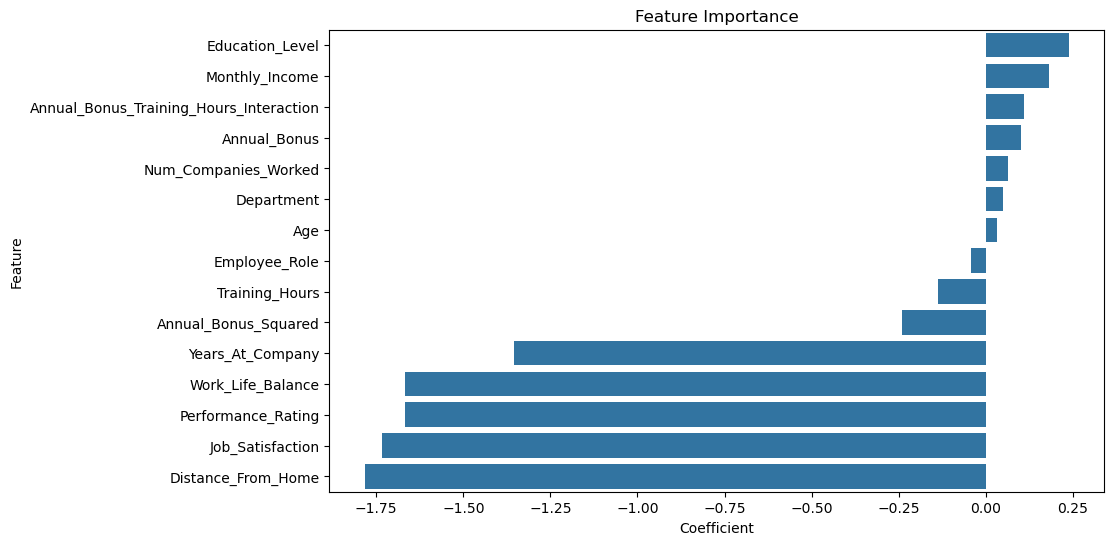

In [38]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=feature_importance,
    x='Coefficient',
    y='Feature'
)

plt.title("Feature Importance")

plt.show()

## Business Insights

Key drivers of employee turnover are identified using model coefficients.

Positive coefficients increase turnover probability.

Negative coefficients reduce turnover probability.

ROC Curve measures the model's ability to distinguish between classes.

In [39]:
coef_df = pd.DataFrame({
    "Feature":X.columns,
    "Coefficient":l2_model.coef_[0]
})

coef_df.sort_values(
    by='Coefficient',
    ascending=False
)

,Feature,Coefficient
6,Education_Level,0.239434
5,Monthly_Income,0.181728
14,Annual_Bonus_Training_Hours_Interaction,0.109494
10,Annual_Bonus,0.102383
8,Num_Companies_Worked,0.064418
12,Department,0.048897
7,Age,0.031348
9,Employee_Role,-0.041778
11,Training_Hours,-0.136064
13,Annual_Bonus_Squared,-0.241330


Positive coefficient → increases turnover probability.

Negative coefficient → decreases turnover probability.

In [40]:
import pickle

pickle.dump(
    l2_model,
    open(
        "employee_turnover_model.pkl",
        "wb"
    )
)

pickle.dump(
    scaler,
    open(
        "scaler.pkl",
        "wb"
    )
)

## Model Saving

The trained model and scaler are saved for deployment in a Streamlit application.

This allows real-time predictions without retraining the model.

# Deployment Preparation

In this section, we prepare files required for deploying the Employee Turnover Prediction model as a Streamlit Web Application.

Files generated:

- employee_turnover_model.pkl
- scaler.pkl
- feature_names.pkl

These files will be loaded by Streamlit.

In [41]:
import pickle

feature_names = list(X.columns)

pickle.dump(
    feature_names,
    open("feature_names.pkl", "wb")
)

print("Feature Names Saved Successfully")

Feature Names Saved Successfully


In [42]:
import os

files = [
    "employee_turnover_model.pkl",
    "scaler.pkl",
    "feature_names.pkl"
]

for file in files:
    print(file, "Exists:", os.path.exists(file))

employee_turnover_model.pkl Exists: True
scaler.pkl Exists: True
feature_names.pkl Exists: True


In [43]:
streamlit_code = r'''
import streamlit as st
import pandas as pd
import numpy as np
import pickle
import plotly.express as px
import plotly.graph_objects as go


# ==================================
# LOAD MODEL
# ==================================

model = pickle.load(
    open(
        "employee_turnover_model.pkl",
        "rb"
    )
)

scaler = pickle.load(
    open(
        "scaler.pkl",
        "rb"
    )
)


# ==================================
# PAGE SETTINGS
# ==================================

st.set_page_config(
    page_title="Employee Turnover Prediction",
    page_icon="📊",
    layout="wide"
)

st.title(
    "📊 Employee Turnover Prediction Dashboard"
)

st.markdown(
"""
Predict employee retention risk using Machine Learning.
"""
)


# ==================================
# SIDEBAR
# ==================================

st.sidebar.header(
    "Employee Information"
)

job = st.sidebar.slider(
    "Job Satisfaction",
    1,
    5,
    3
)

rating = st.sidebar.slider(
    "Performance Rating",
    1,
    5,
    3
)

years = st.sidebar.slider(
    "Years At Company",
    0,
    40,
    5
)

balance = st.sidebar.slider(
    "Work Life Balance",
    1,
    5,
    3
)

distance = st.sidebar.slider(
    "Distance From Home",
    0,
    50,
    10
)

income = st.sidebar.slider(
    "Monthly Income ₹",
    10000,
    300000,
    60000
)

education = st.sidebar.slider(
    "Education Level",
    1,
    5,
    3
)

age = st.sidebar.slider(
    "Age",
    18,
    65,
    30
)

companies = st.sidebar.slider(
    "Companies Worked",
    0,
    20,
    2
)

role = st.sidebar.slider(
    "Employee Role",
    0,
    10,
    5
)

bonus = st.sidebar.slider(
    "Annual Bonus ₹",
    0,
    1000000,
    100000
)

training = st.sidebar.slider(
    "Training Hours",
    0,
    100,
    20
)

department = st.sidebar.slider(
    "Department",
    0,
    10,
    5
)


# ==================================
# NORMALIZE
# ==================================

def normalize(v, low, high):
    return (v - low) / (high - low)


# ==================================
# FEATURE ENGINEERING
# ==================================

annual_bonus_squared = bonus ** 2

bonus_training = (
    bonus * training
)


# ==================================
# INPUT DATA
# ==================================

data = [[

normalize(job,1,5),

normalize(rating,1,5),

normalize(years,0,40),

normalize(balance,1,5),

normalize(distance,0,50),

normalize(income,10000,300000),

normalize(education,1,5),

normalize(age,18,65),

normalize(companies,0,20),

normalize(role,0,10),

normalize(bonus,0,1000000),

normalize(training,0,100),

department,

normalize(
annual_bonus_squared,
0,
1000000**2
),

normalize(
bonus_training,
0,
1000000*100
)

]]

columns = [

"Job_Satisfaction",

"Performance_Rating",

"Years_At_Company",

"Work_Life_Balance",

"Distance_From_Home",

"Monthly_Income",

"Education_Level",

"Age",

"Num_Companies_Worked",

"Employee_Role",

"Annual_Bonus",

"Training_Hours",

"Department",

"Annual_Bonus_Squared",

"Annual_Bonus_Training_Hours_Interaction"

]

input_df = pd.DataFrame(
    data,
    columns=columns
)


# ==================================
# PREDICT
# ==================================

if st.button(
    "🔍 Predict Employee Turnover"
):

    try:

        scaled = scaler.transform(
            input_df
        )

        prediction = model.predict(
            scaled
        )[0]

        probability = model.predict_proba(
            scaled
        )[0]

        stay = (
            probability[0]
            * 100
        )

        leave = (
            probability[1]
            * 100
        )


        st.header(
            "Prediction Result"
        )

        if prediction == 0:

            st.success(
f"""
🟢 Low Retention Risk

Stay Probability:
{stay:.1f}%

Employee shows strong retention indicators.
"""
)

        else:

            st.error(
f"""
🔴 High Attrition Risk

Leave Probability:
{leave:.1f}%

Consider manager review.
"""
)


# ==================================
# KPI
# ==================================

        c1,c2,c3=st.columns(3)

        c1.metric(
            "Stay %",
            f"{stay:.1f}"
        )

        c2.metric(
            "Leave %",
            f"{leave:.1f}"
        )

        c3.metric(
            "Risk",
            "Low"
            if prediction==0
            else
            "High"
        )


# ==================================
# GAUGE
# ==================================

        fig = go.Figure(

            go.Indicator(

                mode="gauge+number",

                value=stay,

                title={
                    "text":
                    "Retention Probability"
                },

                gauge={
                    "axis":{
                        "range":[0,100]
                    }
                }

            )

        )

        st.plotly_chart(
            fig,
            use_container_width=True
        )


# ==================================
# RECOMMENDATION
# ==================================

        st.subheader(
            "HR Recommendation"
        )

        if prediction == 1:

            st.warning(
"""
• Improve engagement

• Review compensation

• Conduct feedback

• Offer growth opportunities
"""
)

        else:

            st.success(
"""
Employee appears stable.

Continue development and recognition.
"""
)


# ==================================
# DETAILS
# ==================================

        with st.expander(
            "Technical Details"
        ):

            st.dataframe(
                input_df
            )


    except Exception as e:

        st.error(
            str(e)
        )


# ==================================
# FOOTER
# ==================================

st.markdown("---")

st.caption(
"""
Built using
Python • Streamlit • Scikit-Learn • Plotly
"""
)

'''

with open("streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)

print("streamlit_app.py created successfully!")

streamlit_app.py created successfully!


In [44]:
with open("streamlit_app.py", "w", encoding="utf-8") as f:
    f.write(streamlit_code)

print("Streamlit App Created Successfully")

Streamlit App Created Successfully


# Running Streamlit

Open Anaconda Prompt

Navigate to project folder

Run:

streamlit run streamlit_app.py

## Key Findings

1. Low Job Satisfaction increases turnover.

2. Poor Work-Life Balance increases resignation chances.

3. Employees with lower income are more likely to leave.

4. Annual Bonus impacts employee retention.

5. Training Hours show relationship with employee engagement.

## Recommendation

The L2 Regularized Logistic Regression model achieved the best balance between:

- Accuracy
- Stability
- Generalization

Therefore, it is recommended as the final production model.

The HR team can use this model to identify high-risk employees and take proactive retention measures.